# Homework 2

## Task 1: Music Streaming Service Analytics

Three sets of user IDs represent listeners of rock, pop, and jazz. Using union, intersection, and difference operations we can determine overall reach, cross-genre listeners, niche audiences, and visualize the overlaps with a Venn diagram.

Total unique listeners: 20

Omnivorous listeners (all 3 genres): {105, 115, 110}, count = 3

Pure rock fans: {109, 107, 101, 118}, count = 4

Users with exactly two genres: {112, 108, 102, 103}, count = 4


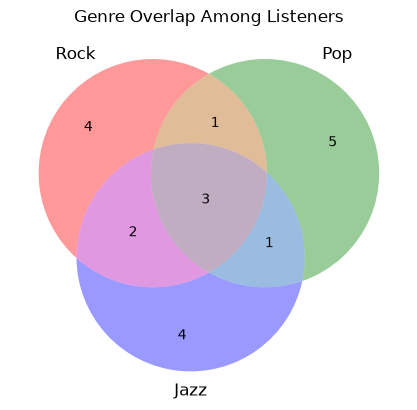

In [1]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

rock_fans = {101, 102, 103, 105, 107, 109, 110, 112, 115, 118}
pop_fans = {102, 104, 105, 106, 108, 110, 111, 113, 115, 117}
jazz_fans = {103, 105, 108, 110, 112, 114, 115, 116, 119, 120}

# total reach: union of all three sets
total_reach = rock_fans | pop_fans | jazz_fans
print(f"Total unique listeners: {len(total_reach)}")

# omnivorous listeners: intersection of all three sets
omnivores = rock_fans & pop_fans & jazz_fans
print(f"\nOmnivorous listeners (all 3 genres): {omnivores}, count = {len(omnivores)}")

# pure rock fans: rock only, no pop, no jazz
pure_rock = rock_fans - pop_fans - jazz_fans
print(f"\nPure rock fans: {pure_rock}, count = {len(pure_rock)}")

# users with exactly two genres
rock_pop = (rock_fans & pop_fans) - jazz_fans
rock_jazz = (rock_fans & jazz_fans) - pop_fans
pop_jazz = (pop_fans & jazz_fans) - rock_fans
exactly_two = rock_pop | rock_jazz | pop_jazz
print(f"\nUsers with exactly two genres: {exactly_two}, count = {len(exactly_two)}")

venn3([rock_fans, pop_fans, jazz_fans], set_labels=('Rock', 'Pop', 'Jazz'))
plt.title("Genre Overlap Among Listeners")
plt.show()

## Task 2: Access Control Configurator (RBAC)

Access to each section depends on a logical combination of five boolean parameters:

$$Base = employee \land verified \land \lnot banned$$
$$Premium = (employee \lor premium) \land verified \land \lnot banned$$
$$Admin = admin \land verified \land \lnot banned$$
$$Secret = (admin \lor (employee \land premium)) \land verified \land \lnot banned$$

In [2]:
from itertools import product

def check_access(is_employee, is_verified, is_premium, is_admin, is_banned):
    base = is_employee and is_verified and not is_banned
    premium = (is_employee or is_premium) and is_verified and not is_banned
    admin = is_admin and is_verified and not is_banned
    secret = (is_admin or (is_employee and is_premium)) and is_verified and not is_banned
    return {'Base': base, 'Premium': premium, 'Admin': admin, 'Secret': secret}

header = f"{'Emp':<6}{'Ver':<6}{'Prem':<6}{'Adm':<6}{'Ban':<6}| {'Base':<6}{'Prem':<6}{'Adm':<6}{'Secr':<6}"
print(header)
print("-" * len(header))

full_access_count = 0
premium_without_base = []

for emp, ver, prem, adm, ban in product([True, False], repeat=5):
    access = check_access(emp, ver, prem, adm, ban)
    row_in = [emp, ver, prem, adm, ban]
    row_out = [access['Base'], access['Premium'], access['Admin'], access['Secret']]

    print("".join(f"{int(v):<6}" for v in row_in) + "| " + "".join(f"{int(v):<6}" for v in row_out))

    if all(row_out):
        full_access_count += 1
    if access['Premium'] and not access['Base']:
        premium_without_base.append((emp, ver, prem, adm, ban))

print(f"\nCases with full access to all 4 sections: {full_access_count}")

print("\nCombinations with Premium access but no Base access:")
for case in premium_without_base:
    print(f"is_employee={case[0]}, is_verified={case[1]}, is_premium={case[2]}, is_admin={case[3]}, is_banned={case[4]}")

print("\nThis happens because Premium access only requires being an employee OR a premium subscriber,")
print("while Base access strictly requires being an employee. A non-employee premium subscriber")
print("therefore gets Premium access but is denied Base access.")

Emp   Ver   Prem  Adm   Ban   | Base  Prem  Adm   Secr  
--------------------------------------------------------
1     1     1     1     1     | 0     0     0     0     
1     1     1     1     0     | 1     1     1     1     
1     1     1     0     1     | 0     0     0     0     
1     1     1     0     0     | 1     1     0     1     
1     1     0     1     1     | 0     0     0     0     
1     1     0     1     0     | 1     1     1     1     
1     1     0     0     1     | 0     0     0     0     
1     1     0     0     0     | 1     1     0     0     
1     0     1     1     1     | 0     0     0     0     
1     0     1     1     0     | 0     0     0     0     
1     0     1     0     1     | 0     0     0     0     
1     0     1     0     0     | 0     0     0     0     
1     0     0     1     1     | 0     0     0     0     
1     0     0     1     0     | 0     0     0     0     
1     0     0     0     1     | 0     0     0     0     
1     0     0     0     0     |

## Task 3: Dream Team Formation

We need to pick 2 back-end developers out of 8, 2 front-end developers out of 6, and 1 designer out of 4. Since order doesn't matter, each choice is a combination $C(n,k) = \binom{n}{k}$. By the multiplication rule, the total number of unique team compositions is:

$$C(8,2) \times C(6,2) \times C(4,1)$$

In [3]:
import math

backend_total, backend_needed = 8, 2
frontend_total, frontend_needed = 6, 2
designer_total, designer_needed = 4, 1

backend_combinations = math.comb(backend_total, backend_needed)
frontend_combinations = math.comb(frontend_total, frontend_needed)
designer_combinations = math.comb(designer_total, designer_needed)

total_teams = backend_combinations * frontend_combinations * designer_combinations

print(f"Back-end combinations: C({backend_total}, {backend_needed}) = {backend_combinations}")
print(f"Front-end combinations: C({frontend_total}, {frontend_needed}) = {frontend_combinations}")
print(f"Designer combinations: C({designer_total}, {designer_needed}) = {designer_combinations}")
print(f"\nTotal unique team compositions: {total_teams}")

Back-end combinations: C(8, 2) = 28
Front-end combinations: C(6, 2) = 15
Designer combinations: C(4, 1) = 4

Total unique team compositions: 1680


## Task 4: Company Social Network Analysis

The undirected graph represents communication between 6 employees: Anna, Bogdan, Viktor, Hanna, Dmytro, and Yevhen. We build an adjacency matrix, an adjacency list, and an edge list, compute the degree of each vertex, and verify the handshake lemma:

$$\sum_{v} deg(v) = 2 \cdot |E|$$

In [4]:
employees = ['Anna', 'Bogdan', 'Viktor', 'Hanna', 'Dmytro', 'Yevhen']

# adjacency list
adjacency_list = {
    'Anna': ['Bogdan', 'Viktor', 'Hanna'],
    'Bogdan': ['Anna', 'Viktor', 'Dmytro'],
    'Viktor': ['Anna', 'Bogdan', 'Hanna', 'Dmytro'],
    'Hanna': ['Anna', 'Viktor', 'Yevhen'],
    'Dmytro': ['Bogdan', 'Viktor', 'Yevhen'],
    'Yevhen': ['Hanna', 'Dmytro']
}

# adjacency matrix
adjacency_matrix = [[1 if other in adjacency_list[person] else 0 for other in employees] for person in employees]

print("Adjacency matrix:")
print(f"{'':<8}" + "".join(f"{name:<8}" for name in employees))
for person, row in zip(employees, adjacency_matrix):
    print(f"{person:<8}" + "".join(f"{v:<8}" for v in row))

# edge list (unique, undirected)
edges = []
for person, neighbors in adjacency_list.items():
    for neighbor in neighbors:
        if (neighbor, person) not in edges:
            edges.append((person, neighbor))

print(f"\nEdge list ({len(edges)} edges):")
print(edges)

# degree of each vertex
degrees = {person: len(neighbors) for person, neighbors in adjacency_list.items()}
print("\nDegrees:")
for person, degree in degrees.items():
    print(f"{person}: {degree}")

most_communicative = max(degrees, key=degrees.get)
least_communicative = min(degrees, key=degrees.get)
print(f"\nMost communicative: {most_communicative} (degree {degrees[most_communicative]})")
print(f"Least communicative: {least_communicative} (degree {degrees[least_communicative]})")

# handshake lemma check
degree_sum = sum(degrees.values())
print(f"\nSum of degrees: {degree_sum}")
print(f"Number of edges: {len(edges)}")
print(f"2 * edges = {2 * len(edges)}")
print(f"Handshake lemma holds: {degree_sum == 2 * len(edges)}")

Adjacency matrix:
        Anna    Bogdan  Viktor  Hanna   Dmytro  Yevhen  
Anna    0       1       1       1       0       0       
Bogdan  1       0       1       0       1       0       
Viktor  1       1       0       1       1       0       
Hanna   1       0       1       0       0       1       
Dmytro  0       1       1       0       0       1       
Yevhen  0       0       0       1       1       0       

Edge list (9 edges):
[('Anna', 'Bogdan'), ('Anna', 'Viktor'), ('Anna', 'Hanna'), ('Bogdan', 'Viktor'), ('Bogdan', 'Dmytro'), ('Viktor', 'Hanna'), ('Viktor', 'Dmytro'), ('Hanna', 'Yevhen'), ('Dmytro', 'Yevhen')]

Degrees:
Anna: 3
Bogdan: 3
Viktor: 4
Hanna: 3
Dmytro: 3
Yevhen: 2

Most communicative: Viktor (degree 4)
Least communicative: Yevhen (degree 2)

Sum of degrees: 18
Number of edges: 9
2 * edges = 18
Handshake lemma holds: True
